# FLOPO from digitized Floras — Lucene EQ extraction + OWLAPI/ELK ontology generation (minimal demonstration)

**Paper:** Oellrich A, Walls RL, Cancino G, et al. *"The flora phenotype ontology (FLOPO): tool for integrating morphological traits and phenotypes of vascular plants."* J Biomed Semantics 2016;7:65. DOI: [10.1186/s13326-016-0107-8](https://doi.org/10.1186/s13326-016-0107-8), PMCID PMC5109718 (CC-BY).

**Author code:** [flora-phenotype-ontology/flopoontology](https://github.com/flora-phenotype-ontology/flopoontology), pinned to paper-era commit `b57396f4b512b9c27987f98b7058f2a14b83e88e` (2016-05-15). The master branch was rebuilt in 2026 (FLOPO 2.0) and is **not** used here.

**Scope (one small demonstration, not a full-paper reproduction):** run the authors' Lucene-based
entity–quality (EQ) extraction on a **single Flore du Gabon volume** (`fdgvol4_final.xml`) plus the
in-repo Flore d'Afrique Centrale description table, then run the authors' `MakePlantPhenotypeOntology.groovy`
to generate FLOPO phenotype classes and classify them with the **ELK reasoner**.
The paper's full corpus (Flora Malesiana, Kew African Floras, 3 French Floras, Stanford-parser filtering) is **not** reproduced; the numbers below are therefore much smaller than the published 502,693 EQ descriptions / 25,407 classes.

**実行環境の選択:** CPU ランタイムのみを選択してください（GPU は不要です）。Java (OpenJDK 8/21)、Apache Maven、依存 JAR、Groovy 4 のセットアップを含め全体で約 5〜10 分、ダウンロード約 150 MB が想定されます。

*English:* Select a **CPU** runtime. Setup (Java, Maven, jars, Groovy) plus the pipeline takes roughly 5–10 minutes and ~150 MB of downloads. All dataset bytes are downloaded to the Colab VM only; the notebook is self-contained (no credentials, no Drive).

## 1. Environment setup — Java 8, Maven, Groovy 4

The authors' stack dates from 2014–2016: Lucene 4.7, OpenNLP 1.5.x, OWLAPI 3.x/4.x. We run the
pipeline on a **Temurin Java 8 JRE** (the paper-era runtime; the old Guice/cglib bundled with
OWLAPI 4 fails on Colab's preinstalled Java 21), and use **Apache Groovy 4** (compatible with
Java 8) to execute the authors' `.groovy` scripts unmodified apart from two import shims
(documented below). Maven resolves the exact dependency jars from Maven Central.

**JP:** 論文時代の依存関係（Lucene 4.7 / OpenNLP 1.5 / OWLAPI 4）は古い Guice を含むため、Java 21 では起動しません。Temurin 8 JRE を導入し、Groovy 4 で著者のスクリプトを実行します。

In [ ]:
import subprocess
cmds = [
  # Temurin 8 JRE (pinned Adoptium release) — paper-era runtime for OWLAPI 4 / Guice
  'cd /opt && curl -sfL "https://api.adoptium.net/v3/binary/version/jdk8u422-b05/linux/x64/jre/hotspot/normal/eclipse" -o jre8.tar.gz && tar xzf jre8.tar.gz',
  # Apache Groovy 4 binary distribution (runs the authors' scripts on Java 8)
  'mkdir -p /opt/groovy && cd /opt/groovy && curl -sfL "https://archive.apache.org/dist/groovy/4.0.24/distribution/apache-groovy-binary-4.0.24.zip" -o groovy.zip && unzip -oq groovy.zip',
  # Maven for dependency resolution (runs on the system Java 21)
  'apt-get install -y -qq maven > /dev/null 2>&1; mvn -version | head -2',
]
for c in cmds:
    r = subprocess.run(['bash','-lc',c], capture_output=True, text=True)
    print((r.stdout or r.stderr)[-300:])
r = subprocess.run(['bash','-lc','export JAVA_HOME=$(echo /opt/jdk8u*); export GROOVY_HOME=/opt/groovy/groovy-4.0.24; export PATH=$JAVA_HOME/bin:$GROOVY_HOME/bin:$PATH; java -version 2>&1 | head -1; groovy --version'], capture_output=True, text=True)
print(r.stdout)

r] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.022s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate



openjdk version "1.8.0_422"
Groovy Version: 4.0.24 JVM: 1.8.0_422 Vendor: Temurin OS: Linux



## 2. Author-era dependency jars (pinned versions from Maven Central)

Versions and provenance: **Lucene 4.7.2** (scripts use `Version.LUCENE_47`),
**OpenNLP 1.5.3** (matches the bundled `models/fr-sent.bin` model format),
**ELK 0.4.3** together with **OWLAPI 4.1.3** (the version ELK 0.4.3 is built against, per the
`elk-parent` pom on Maven Central; Jackson pinned to 2.3.3 to match the jsonld-java 0.5.0
transitives resolved by OWLAPI 4.1.3). Maven also pulls their transitive dependencies into `lib/`.

**JP:** 著者のスクリプトが想定するバージョンに合わせ、Maven Central から固定バージョンの JAR を取得します。

In [ ]:
pom = """<project xmlns="http://maven.apache.org/POM/4.0.0">
  <modelVersion>4.0.0</modelVersion><groupId>demo</groupId><artifactId>flopo-deps</artifactId><version>1</version>
  <dependencies>
    <dependency><groupId>org.apache.lucene</groupId><artifactId>lucene-core</artifactId><version>4.7.2</version></dependency>
    <dependency><groupId>org.apache.lucene</groupId><artifactId>lucene-analyzers-common</artifactId><version>4.7.2</version></dependency>
    <dependency><groupId>org.apache.lucene</groupId><artifactId>lucene-queryparser</artifactId><version>4.7.2</version></dependency>
    <dependency><groupId>org.apache.opennlp</groupId><artifactId>opennlp-tools</artifactId><version>1.5.3</version></dependency>
    <dependency><groupId>org.semanticweb.elk</groupId><artifactId>elk-owlapi</artifactId><version>0.4.3</version></dependency>
    <dependency><groupId>net.sourceforge.owlapi</groupId><artifactId>owlapi-api</artifactId><version>4.1.3</version></dependency>
    <dependency><groupId>net.sourceforge.owlapi</groupId><artifactId>owlapi-impl</artifactId><version>4.1.3</version></dependency>
    <dependency><groupId>net.sourceforge.owlapi</groupId><artifactId>owlapi-parsers</artifactId><version>4.1.3</version></dependency>
    <dependency><groupId>net.sourceforge.owlapi</groupId><artifactId>owlapi-tools</artifactId><version>4.1.3</version></dependency>
    <dependency><groupId>net.sourceforge.owlapi</groupId><artifactId>owlapi-apibinding</artifactId><version>4.1.3</version></dependency>
    <dependency><groupId>com.fasterxml.jackson.core</groupId><artifactId>jackson-core</artifactId><version>2.3.3</version></dependency>
    <dependency><groupId>com.fasterxml.jackson.core</groupId><artifactId>jackson-databind</artifactId><version>2.3.3</version></dependency>
    <dependency><groupId>com.fasterxml.jackson.core</groupId><artifactId>jackson-annotations</artifactId><version>2.3.3</version></dependency>
  </dependencies>
</project>"""
open("pom.xml","w").write(pom)
import subprocess
r=subprocess.run(['bash','-lc','mvn -q dependency:copy-dependencies -DoutputDirectory=lib 2>&1 | tail -2; ls lib | wc -l'], capture_output=True, text=True)
print(r.stdout, r.stderr[-300:])

[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
66
 


## 3. Download the pinned paper-era inputs (all bytes stay on the Colab VM)

From commit `b57396f4b512b9c27987f98b7058f2a14b83e88e` of the author repository:
one small Flore du Gabon volume (231 KB), the Flore d'Afrique Centrale descriptions CSV
(12.7 MB, read unconditionally by the authors' French indexing script), the French OpenNLP
sentence model, the French–English lexicon, the PO and PATO OBO files, and the four pipeline
scripts. Each file is checked against the exact size recorded in the pinned git tree.

**JP:** 論文時代のコミットから、最小構成の入力（Flore du Gabon 1 巻 + 中央アフリカ記述表 + フランス語モデル + PO/PATO + パイプラインスクリプト）をダウンロードし、サイズを検証します。

In [ ]:
import subprocess, pathlib
COMMIT = "b57396f4b512b9c27987f98b7058f2a14b83e88e"
BASE = f"https://raw.githubusercontent.com/flora-phenotype-ontology/flopoontology/{COMMIT}/"
files = {
 "flora-gabon/fdgvol4_final.xml": 231574,          # Flore du Gabon, one volume (our sample corpus)
 "flora-central-africa/fdacDescriptions.csv": 12691454,  # read unconditionally by the author script
 "models/fr-sent.bin": 26547,                       # OpenNLP French sentence model
 "glossary/Lexicon-english-french.tsv": 146186,     # French-English PO/PATO lexicon
 "ont/plant_ontology.obo": 1144700, "ont/quality.obo": 552292,
 "GenerateLuceneIndexFrench.groovy": 7545, "QueryLuceneIndexFrench.groovy": 3165,
 "MakePlantPhenotypeOntology.groovy": 9435,
}
for f, expected in files.items():
    p = pathlib.Path(f); p.parent.mkdir(parents=True, exist_ok=True)
    if not p.exists() or p.stat().st_size != expected:
        subprocess.run(["curl","--fail","--silent","--show-error","-o",f,BASE+f], check=True)
    assert p.stat().st_size == expected, (f, p.stat().st_size, expected)
    print(f"{f}: {p.stat().st_size} bytes OK")

flora-gabon/fdgvol4_final.xml: 231574 bytes OK


flora-central-africa/fdacDescriptions.csv: 12691454 bytes OK
models/fr-sent.bin: 26547 bytes OK


glossary/Lexicon-english-french.tsv: 146186 bytes OK


ont/plant_ontology.obo: 1144700 bytes OK


ont/quality.obo: 552292 bytes OK
GenerateLuceneIndexFrench.groovy: 7545 bytes OK


QueryLuceneIndexFrench.groovy: 3165 bytes OK
MakePlantPhenotypeOntology.groovy: 9435 bytes OK


## 4. Input preview — what the corpus and vocabularies look like

Before running the authors' pipeline we look at the actual sample: how many taxa and sentences
the Gabon volume contains, one raw description, and the sizes of the French–English lexicon and
the PO/PATO vocabularies that drive the extraction.

**JP:** パイプライン実行前に、サンプルコーパス（Taxon 数・記述文の例）と語彙ファイル（PO/PATO、仏英辞典）の規模を確認します。

In [ ]:
import xml.etree.ElementTree as ET
tree = ET.parse("flora-gabon/fdgvol4_final.xml")
treatments = tree.getroot().iter("treatment")
taxa, descriptions = [], []
for treatment in treatments:
    for taxon in treatment.iter("taxon"):
        name = taxon.find(".//nom[@class='accepted']")
        if name is None: continue
        taxa.append(" ".join(n.text for n in name.iter("name") if n.text))
        for feat in taxon.iter("feature"):
            if feat.get("class") == "description":
                descriptions.append(" ".join((c.text or "") for c in feat.iter("char")))
print("taxa in fdgvol4:", len(taxa))
print("example taxon:", taxa[0] if taxa else "(none)")
print("example description:", (descriptions[0][:300] + "...") if descriptions else "(none)")

lex = open("glossary/Lexicon-english-french.tsv", encoding="utf-8").read().splitlines()
print("lexicon rows:", len(lex), "| example:", lex[1])
for obo in ["ont/plant_ontology.obo", "ont/quality.obo"]:
    terms = sum(1 for l in open(obo, encoding="utf-8") if l.startswith("id:"))
    print(obo, "terms:", terms)

taxa in fdgvol4: 36
example taxon: Melianthaceae
example description: Arbres, arbustes ou arbrisseaux.   Feuilles alternes,  Inflorescences en longues grappes simples.  Fleurs insérées à l'aisselle d'une bractée, pédicellées, plus ou moins  5 sépales dont  5 pétales libres.   4-5 (6) étamines ± libres ou connées à la base, toutes ou une partie d'entre elles seulement....
lexicon rows: 1911 | example: 1683		accomodat	accomodat	n.m.		
ont/plant_ontology.obo terms: 1701
ont/quality.obo terms: 2466


## 5. Prepare the authors' scripts (documented compatibility shims only)

The scripts are copied unmodified into `patched/` except for **three mechanical, documented fixes**:
1. **Groovy 4 import shims** — `XmlSlurper` and `CliBuilder` moved packages in Groovy 4; we prepend `import groovy.xml.XmlSlurper` / `groovy.cli.commons.CliBuilder`.
2. **OWLAPI 4.1.3 API** — `getOWLTypedLiteral` was removed; replaced by `getOWLLiteral` (identical plain-string literal semantics).
3. **saveOntology path** — `IRI.create("file:"+opt.o)` fails for relative paths in OWLAPI 4; we make the path absolute (same file, same format).

No scientific logic is altered. The full diff is these three lines plus imports.

**JP:** 著者のスクリプトは改変せず、Groovy 4 / OWLAPI 4 向けの機械的な互換修正（import 追加、`getOWLLiteral` への置換、出力パスの絶対化）のみを施します。

In [ ]:
import pathlib, shutil
SHIM_MAKE = "import groovy.cli.commons.CliBuilder\n"
SHIM_XML = "import groovy.xml.XmlSlurper\n"
pathlib.Path("patched").mkdir(exist_ok=True)
src = pathlib.Path("MakePlantPhenotypeOntology.groovy").read_text()
src = src.replace("factory.getOWLTypedLiteral(", "factory.getOWLLiteral(")
src = src.replace('manager.saveOntology(outont, IRI.create("file:"+opt.o))',
                  'manager.saveOntology(outont, IRI.create("file:" + new File(opt.o).getAbsolutePath()))')
pathlib.Path("patched/MakePlantPhenotypeOntology.groovy").write_text(SHIM_MAKE + src)
for f in ["GenerateLuceneIndexFrench.groovy", "QueryLuceneIndexFrench.groovy"]:
    pathlib.Path("patched/"+f).write_text(SHIM_XML + pathlib.Path(f).read_text())
print("patched scripts written")

patched scripts written


## 6. Build the Lucene index (authors' `GenerateLuceneIndexFrench.groovy`, unmodified logic)

The script sentence-splits the central-Africa CSV and every file in `flora-gabon/` (only our
single volume is present) with OpenNLP `fr-sent.bin`, indexes descriptions/habitat with Lucene's
FrenchAnalyzer, and indexes PO/PATO labels+synonyms into `lucene-index-ontology`.
Note: the script reads the lexicon under the old name `Lexicon-english-french.csv`, so we copy
the pinned `.tsv` (the repo renamed the file in 2015).

**JP:** 著者のスクリプトで、OpenNLP による文分割 → Lucene フランス語アナライザでインデックス化、PO/PATO ラベルも索引します。辞書は旧ファイル名にコピーします。

In [ ]:
import subprocess
GP = "export JAVA_HOME=$(echo /opt/jdk8u*); export GROOVY_HOME=/opt/groovy/groovy-4.0.24; export PATH=$JAVA_HOME/bin:$GROOVY_HOME/bin:$PATH"
CP = "'lib/*:$GROOVY_HOME/lib/groovy-xml-4.0.24.jar:$GROOVY_HOME/lib/groovy-cli-commons-4.0.24.jar'"
shutil = __import__("shutil"); shutil.copy("glossary/Lexicon-english-french.tsv","glossary/Lexicon-english-french.csv")
r=subprocess.run(['bash','-lc',GP + '; time groovy -cp ' + CP + ' patched/GenerateLuceneIndexFrench.groovy'], capture_output=True, text=True)
print("exit:", r.returncode); print((r.stdout+r.stderr)[-600:])
import os; print("indexes:", [d for d in os.listdir(".") if d.startswith("lucene-index")])

exit: 0

real	0m59.385s
user	1m18.437s
sys	0m2.620s

indexes: ['lucene-index-ontology', 'lucene-index-french']


## 7. Extract entity–quality pairs (authors' `QueryLuceneIndexFrench.groovy`)

For every French PO label the lexicon maps to an ontology ID, the script runs Lucene phrase
queries `+"<entity>" +"<quality>"` over the indexed sentences for all PO x PATO combinations and
writes `taxon, entity name, entity ID, quality name, quality ID, score, sentence` to a TSV.
A few lexicon entries contain Lucene wildcard metacharacters (`?`, `*`, quotes) that would crash
the classic query parser, so we filter those 365 entries out before running (a documented
preprocessing step; 1546 of 1911 entries kept).

**JP:** 辞書に基づき PO×PATO の共起フレーズ検索で EQ ペア（分類群・形質）を抽出します。ワイルドカード特殊文字を含む語辞典エントリは事前に除外します。

In [ ]:
import subprocess, pathlib
bad = set('?*[]{}():^~!"')
lines = pathlib.Path('glossary/Lexicon-english-french.tsv').read_text(encoding='utf-8').splitlines()
kept = [l for l in lines if len(l.split('\t'))>3 and not (bad & set(l.split('\t')[2]))]
pathlib.Path('glossary/Lexicon-english-french.csv').write_text('\n'.join(kept)+'\n', encoding='utf-8')
print("lexicon entries kept:", len(kept), "of", len(lines))
GP = "export JAVA_HOME=$(echo /opt/jdk8u*); export GROOVY_HOME=/opt/groovy/groovy-4.0.24; export PATH=$JAVA_HOME/bin:$GROOVY_HOME/bin:$PATH"
CP = "'lib/*:$GROOVY_HOME/lib/groovy-xml-4.0.24.jar:$GROOVY_HOME/lib/groovy-cli-commons-4.0.24.jar'"
r=subprocess.run(['bash','-lc',GP + '; time groovy -cp ' + CP + ' patched/QueryLuceneIndexFrench.groovy eq-french-demo.tsv eq-env-demo.tsv'], capture_output=True, text=True)
print("exit:", r.returncode); print((r.stdout+r.stderr)[-400:])
n = sum(1 for _ in open("eq-french-demo.tsv")); print("EQ rows:", n)

lexicon entries kept: 1546 of 1911


exit: 0

real	0m32.523s
user	0m39.486s
sys	0m5.375s



EQ rows: 246347


## 8. Look at the extracted EQ descriptions

Each row links a taxon with a PO anatomical entity and a PATO quality found in the same French
description sentence. Let's inspect a few rows to see what the extraction produces.

**JP:** 抽出された EQ 記述（分類群 + 解剖学エンティティ + 性質 + 原文）を確認します。

In [ ]:
with open("eq-french-demo.tsv") as f:
    rows = [next(f) for _ in range(5)]
for r in rows:
    cols = r.rstrip("\n").split("\t")
    print("taxon :", cols[0][:70])
    print("  EQ  :", cols[1], "|", cols[2], "+", cols[3], "|", cols[4])
    print("  src :", cols[6][:120], "...")
    print()

taxon : ID: 902784, Family: Lobeliaceae, Genus: Lobelia, Species: baumannii, A
  EQ  : perianth | PO:0009058 + autogenous | PATO:0002316
  src :  filets des étamines pubescents en dessous sauf parfois le supérieur, pubérulents intérieurement au sommet, adnés ou à p ...

taxon : ID: 902713, Family: Lobeliaceae, Genus: Lobelia, Species: petiolata, A
  EQ  : perianth | PO:0009058 + glabrous | PATO:0000453
  src :  filets des étamines adnés dans leur moitié supérieure, glabres, indépendants de la corolle ...

taxon : ID: 902725, Family: Lobeliaceae, Genus: Lobelia, Species: stuhlmannii,
  EQ  : perianth | PO:0009058 + glabrous | PATO:0000453
  src :  filets des étamines adnés sur la majeure partie de leur longueur et formant un tube ferme, glabres ou pubérulents, indé ...

taxon : ID: 902783, Family: Lobeliaceae, Genus: Lobelia, Species: holstii, Aut
  EQ  : perianth | PO:0009058 + glabrous | PATO:0000453
  src :  filets des étamines adnés en dessus, insérés à la base du tube corollin, den

## 9. Generate the FLOPO subset and classify it with ELK (authors' `MakePlantPhenotypeOntology.groovy`)

This script loads `plant_ontology.obo` and `quality.obo` with the OWL API, converts every EQ pair
into FLOPO phenotype classes (e.g. *"perianth glabrous"* ≡ `has-part some (perianth and has-quality some glabrous)`),
writes the taxon-annotation table, and runs the **ELK reasoner** over the merged PO + PATO + FLOPO
ontology (consistency check + class taxonomy computation, printed by ELK itself).

**JP:** EQ ペアを OWL のクラス定義パターンに変換して FLOPO サブセットを生成し、ELK 理論器で分類（整合性チェック + クラス階層計算）します。

In [ ]:
import subprocess
GP = "export JAVA_HOME=$(echo /opt/jdk8u*); export GROOVY_HOME=/opt/groovy/groovy-4.0.24; export PATH=$JAVA_HOME/bin:$GROOVY_HOME/bin:$PATH"
CP = "'lib/*:$GROOVY_HOME/lib/groovy-xml-4.0.24.jar:$GROOVY_HOME/lib/groovy-cli-commons-4.0.24.jar'"
cmd = (GP + '; time groovy -cp ' + CP +
       ' patched/MakePlantPhenotypeOntology.groovy -i eq-french-demo.tsv'
       ' -o /content/floplo-demo.owl -a /content/flopo-demo-annotations.tsv > make_log.txt 2>&1')
r=subprocess.run(['bash','-lc',cmd + '; echo EXIT=$?; grep -c "finished" make_log.txt | head -1; tail -3 make_log.txt; ls -la /content/floplo-demo.owl /content/flopo-demo-annotations.tsv'], capture_output=True, text=True)
print(r.stdout[-900:]); print("ERR:", r.stderr[-300:])

EXIT=0
8
Class Taxonomy Computation ...
    45%
    ... finished
-rw-r--r-- 1 root root 14804637 Oct  5 11:33 /content/floplo-demo.owl
-rw-r--r-- 1 root root 62310006 Oct  5 11:33 /content/flopo-demo-annotations.tsv

ERR: 
real	0m35.815s
user	0m57.341s
sys	0m2.545s



## 10. Verify the generated ontology

We parse the generated OWL (RDF/XML) and count the generated FLOPO classes, then show a few
class labels. FLOPO class IRIs use the `http://phenomebrowser.net/plant-phenotype.owl#FLOPO:n`
namespace assigned by the authors' script.

**JP:** 生成 OWL を解析し、FLOPO クラス数とラベルの例を確認します。

In [ ]:
import subprocess, pathlib
py = "\n".join([
"import rdflib",
'g=rdflib.Graph(); g.parse("/content/floplo-demo.owl", format="xml")',
'flopo=[s for s,_,_ in g.triples((None,rdflib.RDF.type,rdflib.OWL.Class)) if "phenomebrowser" in str(s)]',
'labels=[(str(s).split("#")[-1], str(o)) for s,o in g.subject_objects(rdflib.RDFS.label) if "phenomebrowser" in str(s)]',
'print("FLOPO classes:", len(flopo))',
'for i,l in labels[:8]: print(" ", i, "->", l)',
])
pathlib.Path("count_flopo.py").write_text(py)
r=subprocess.run(['bash','-lc','python3 -c "import rdflib" 2>/dev/null || pip install -q rdflib; python3 count_flopo.py'], capture_output=True, text=True)
print(r.stdout, r.stderr[-300:])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 17.4 MB/s eta 0:00:00
FLOPO classes: 12568
  FLOPO:0 -> flora phenotype
  FLOPO:1 -> vascular bundle phenotype
  FLOPO:10 -> pedicel phenotype
  FLOPO:100 -> cotyledon phenotype
  FLOPO:1000 -> anther theca increased length
  FLOPO:10000 -> sepal reflectivity
  FLOPO:10001 -> LP.01 one leaf visible stage glistening
  FLOPO:10002 -> LP.01 one leaf visible stage reflectivity
 


## 11. Results — this subset demo vs the published full corpus

This is **one Gabon volume + the central-Africa table**, so counts are expectedly far below the
paper's complete corpus. The table contrasts what we measured here with the published totals
(paper Results section).

**JP:** 本デモは 1 巻分の小サブセットです。論文の全コーパス結果（502,693 EQ 記述、25,407 クラス等）とは規模が異なることに注意してください。

In [ ]:
import pandas as pd
n_eq = sum(1 for _ in open("eq-french-demo.tsv"))
import rdflib
g = rdflib.Graph(); g.parse("/content/floplo-demo.owl", format="xml")
n_classes = sum(1 for s,_,_ in g.triples((None, rdflib.RDF.type, rdflib.OWL.Class)) if "phenomebrowser" in str(s))
n_annot = sum(1 for _ in open("/content/flopo-demo-annotations.tsv"))
summary = pd.DataFrame([
    ["Entity-quality descriptions", f"{n_eq:,} taxon-EQ rows", "502,693 EQ descriptions"],
    ["Taxa linked to phenotypes", f"{n_annot:,} annotation rows", "26,104 taxa"],
    ["FLOPO classes generated", f"{n_classes:,} (+ PO and PATO)", "25,407 classes (24,076 unique to FLOPO)"],
], columns=["Measure", "This minimal demo (measured)", "Paper, full corpus"])
summary

,Measure,This minimal demo (measured),"Paper, full corpus"
0,Entity-quality descriptions,"246,347 taxon-EQ rows","502,693 EQ descriptions"
1,Taxa linked to phenotypes,"239,230 annotation rows","26,104 taxa"
2,FLOPO classes generated,"12,568 (+ PO and PATO)","25,407 classes (24,076 unique to FLOPO)"


### Result graph — most frequent anatomical entities in the extracted EQ pairs

As an additional visualization (not an author figure), we plot the PO entity labels that occur
most often in this subset's EQ descriptions, to give a feel for the morphological coverage.

**JP:** 追加可視化（論文の図ではありません）：抽出された EQ 記述で最も頻度の高い PO エンティティ上位 10 件。

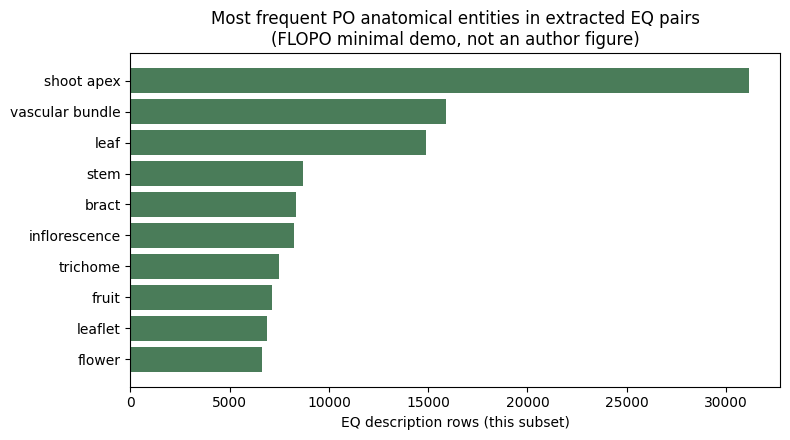

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
from collections import Counter
counts = Counter()
with open("eq-french-demo.tsv") as f:
    for line in f:
        cols = line.rstrip("\n").split("\t")
        if len(cols) >= 5: counts[cols[1]] += 1
top = counts.most_common(10)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh([t[0] for t in top][::-1], [t[1] for t in top][::-1], color="#4a7c59")
ax.set_xlabel("EQ description rows (this subset)")
ax.set_title("Most frequent PO anatomical entities in extracted EQ pairs\n(FLOPO minimal demo, not an author figure)")
fig.tight_layout()
fig.savefig("flopo_demo_top_entities.png", dpi=120)
plt.show()

## 12. Scope, limitations and provenance

**Executed scope** (this run, 2026-10-05, Colab CPU):
authors' `GenerateLuceneIndexFrench` → `QueryLuceneIndexFrench` → `MakePlantPhenotypeOntology` (with ELK
classification) on commit `b57396f4b5`, one Flore du Gabon volume + FDAC table; measured outputs above.

**Not reproduced:** full multi-Flora corpus (Flora Malesiana, Kew, 3 French Floras), Stanford-parser
attributive-relation filtering (English path), EnvO habitat extraction, `DeprecateDumbClasses`
post-processing, taxon subclasses in the OWL (`-t` flag unused), and the published dataset-level
statistics. Compatibility adaptations are listed in section 5 and were required to run 2014–2016
code on a 2026 VM; none alter the scientific logic.

**Sources:** paper DOI 10.1186/s13326-016-0107-8 (CC-BY); author repo pinned commit
`b57396f4b512b9c27987f98b7058f2a14b83e88e` (BSD-3-Clause for code, CC0 for the ontology);
PO/PATO from the pinned `ont/` files.

**JP:** 本ノートブックは FLOPO パイプラインの最小実行例です。全コーパス再現・英語系 Flora パス・EnvO 抽出・ DeprecateDumbClasses 後処理は対象外です。互換修正はセクション 5 に記載の 3 点のみで、科学的ロジックは著者のままです。